In [49]:
import pandas as pd
from scipy.io import arff
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

In [43]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 1.1 MB/s eta 0:00:43
    --------------------------------------- 1.0/48.9 MB 1.3 MB/s eta 0:00:37
   - -------------------------------------- 1.3/48.9 MB 1.4 MB/s eta 0:00:35
   - -------------------------------------- 1.3/48.9 MB 1.4 MB/s eta 0:00:35
   - -------------------------------------- 1.6/48.9 MB 1.2 MB/s eta 0:00:40
   - -------------------------------------- 2.1/48.9 MB 1.3 MB/s eta 0:00:37
   - -------------------------------------- 2.4/48.9 MB 1.4 MB/s eta 0:00:35
   -- ------------------------------------- 2.6/48.9 MB 1.3 MB/s eta 0:00:35
   -- ------------------------------------- 3.1/48.9 MB 1.4 MB/s eta 0:00:33
   -- ------------------------------------- 3.7/48.9 MB 1.5 MB/s eta 0:00:31
   --- -------------

In [45]:
import xgboost as xgb

In [10]:
freq_dataset = fetch_openml(data_id=41214, as_frame=True, parser='auto')
df_freq = freq_dataset.frame

sev_dataset = fetch_openml(data_id=41215, as_frame=True, parser='auto')
df_sev = sev_dataset.frame

print(df_freq.head())
print(df_sev.head())

   IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0    1.0        1      0.10    D         5       0       55          50   
1    3.0        1      0.77    D         5       0       55          50   
2    5.0        1      0.75    B         6       2       52          50   
3   10.0        1      0.09    B         7       0       46          50   
4   11.0        1      0.84    B         7       0       46          50   

  VehBrand     VehGas  Density Region  
0      B12  'Regular'     1217    R82  
1      B12  'Regular'     1217    R82  
2      B12   'Diesel'       54    R22  
3      B12   'Diesel'       76    R72  
4      B12   'Diesel'       76    R72  
     IDpol  ClaimAmount
0     1552       995.20
1  1010996      1128.12
2  4024277      1851.11
3  4007252      1204.00
4  4046424      1204.00


In [15]:
df_sev_agg = df_sev.groupby('IDpol')['ClaimAmount'].sum().reset_index()

df_sev_agg = df_sev_agg.rename(columns={'ClaimAmount': 'Total_Claim_Amount'})

df_master = df_freq.merge(df_sev_agg, on='IDpol', how='left')

df_master['Total_Claim_Amount'] = df_master['Total_Claim_Amount'].fillna(0)

print(f"Original Frequency Shape: {df_freq.shape}")
print(f"New Master Shape: {df_master.shape}")
print(df_master[['IDpol', 'ClaimNb', 'Total_Claim_Amount']].head(10))

Original Frequency Shape: (678013, 12)
New Master Shape: (678013, 13)
   IDpol  ClaimNb  Total_Claim_Amount
0    1.0        1                 0.0
1    3.0        1                 0.0
2    5.0        1                 0.0
3   10.0        1                 0.0
4   11.0        1                 0.0
5   13.0        1                 0.0
6   15.0        1                 0.0
7   17.0        1                 0.0
8   18.0        1                 0.0
9   21.0        1                 0.0


In [18]:
df_master['Pure_Premium'] = df_master['Total_Claim_Amount'] / df_master['Exposure']

df_master['Frequency'] = df_master['ClaimNb'] / df_master['Exposure']

df_master['Severity'] = np.where(
    df_master['ClaimNb'] > 0, 
    df_master['Total_Claim_Amount'] / df_master['ClaimNb'], 0
)

In [19]:
threshold = df_master.loc[df_master['Total_Claim_Amount'] > 0, 'Total_Claim_Amount'].quantile(0.99)
print(f"Capping threshold: €{threshold:,.2f}")

df_master['Total_Claim_Amount_Capped'] = df_master['Total_Claim_Amount'].clip(upper=threshold)

df_master['Pure_Premium_Capped'] = df_master['Total_Claim_Amount_Capped'] / df_master['Exposure']

Capping threshold: €18,278.38


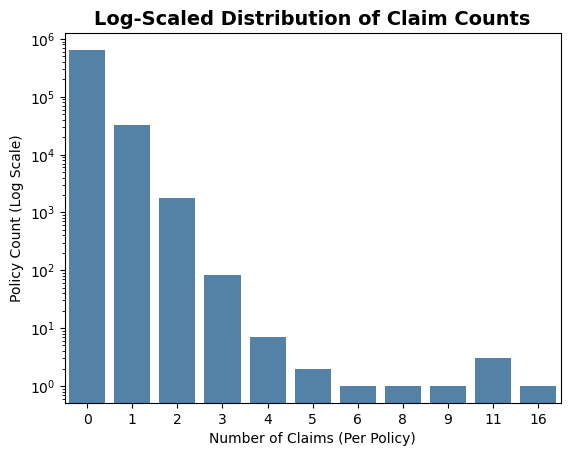

In [24]:
plt.title('Log-Scaled Distribution of Claim Counts', fontsize=14, fontweight='bold')
ax = sns.countplot(data=df_master, x='ClaimNb', color='steelblue')
ax.set_yscale('log')
plt.xlabel('Number of Claims (Per Policy)')
plt.ylabel('Policy Count (Log Scale)')
plt.show()

In [29]:
freq_formula = "ClaimNb ~ BonusMalus + DrivAge + VehAge + C(VehGas)"

# Poisson of Claims
freq_model = smf.glm(
    formula=freq_formula,
    data=df_master,
    family=sm.families.Poisson(link=sm.families.links.Log()),
    offset=np.log(df_master['Exposure'])
).fit()
print(freq_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   678008
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4357e+05
Date:                Sun, 04 Oct 2026   Deviance:                   2.1782e+05
Time:                        14:19:46   Pearson chi2:                 1.83e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.009776
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -3

In [32]:
# Note: I initially used df_master['ClaimNB'] > 0. However, it seems there were claims that did not require any pay because they had a 
# deductible. I then needed to set it as Severity instead in order to avoid any /0 errors. 

df_claims = df_master[df_master['Severity'] > 0].copy()

sev_formula = "Severity ~ BonusMalus + DrivAge + VehAge + C(VehGas)"

# Gamma of severity
sev_model = smf.glm(
    formula=sev_formula,
    data=df_claims,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    var_weights=df_claims['ClaimNb']
).fit()

print(sev_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               Severity   No. Observations:                24944
Model:                            GLM   Df Residuals:                    24939
Model Family:                   Gamma   Df Model:                            4
Link Function:                    Log   Scale:                          83.009
Method:                          IRLS   Log-Likelihood:            -2.8201e+05
Date:                Sun, 04 Oct 2026   Deviance:                       43529.
Time:                        14:24:00   Pearson chi2:                 2.07e+06
No. Iterations:                    26   Pseudo R-squ. (CS):          0.0007222
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  7

In [33]:
tweedie_formula = "Pure_Premium_Capped ~ BonusMalus + DrivAge + VehAge + C(VehGas)"

tweedie_model = smf.glm(
    formula=tweedie_formula,
    data=df_master,
    family=sm.families.Tweedie(link=sm.families.links.Log(), var_power=1.5),
    var_weights=df_master['Exposure']
).fit()

print(tweedie_model.summary())

                  Generalized Linear Model Regression Results                  
Dep. Variable:     Pure_Premium_Capped   No. Observations:               678013
Model:                             GLM   Df Residuals:                   678008
Model Family:                  Tweedie   Df Model:                            4
Link Function:                     Log   Scale:                          1345.7
Method:                           IRLS   Log-Likelihood:            -3.6384e+05
Date:                 Sun, 04 Oct 2026   Deviance:                   2.4346e+07
Time:                         14:33:36   Pearson chi2:                 9.12e+08
No. Iterations:                     15   Pseudo R-squ. (CS):           0.001075
Covariance Type:             nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept         

In [34]:
#Poisson*Gamma
df_master['Pred_Freq'] = freq_model.predict(df_master)
df_master['Pred_Sev'] = sev_model.predict(df_master)
df_master['Pred_PP_TwoStep'] = df_master['Pred_Freq'] * df_master['Pred_Sev']

#Tweedie
df_master['Pred_PP_Tweedie'] = tweedie_model.predict(df_master)

In [36]:
def calculate_lorenz_and_gini(df, pred_col, actual_loss_col, exposure_col):
    df_sorted = df.sort_values(by=pred_col)

    cum_exposure = df_sorted[exposure_col].cumsum()
    cum_exposure_pct = cum_exposure / cum_exposure.max()

    cum_losses = df_sorted[actual_loss_col].cumsum()
    cum_losses_pct = cum_losses / cum_losses.max()
    cum_exposure_pct = np.append([0], cum_exposure_pct)
    cum_losses_pct = np.append([0], cum_losses_pct)

    auc = np.trapezoid(cum_losses_pct, cum_exposure_pct)
    gini = 1 - 2 * auc
    
    return cum_exposure_pct, cum_losses_pct, gini

x_two, y_two, gini_two = calculate_lorenz_and_gini(
    df_master, 'Pred_PP_TwoStep', 'Total_Claim_Amount_Capped', 'Exposure'
)

x_tw, y_tw, gini_tw = calculate_lorenz_and_gini(
    df_master, 'Pred_PP_Tweedie', 'Total_Claim_Amount_Capped', 'Exposure'
)

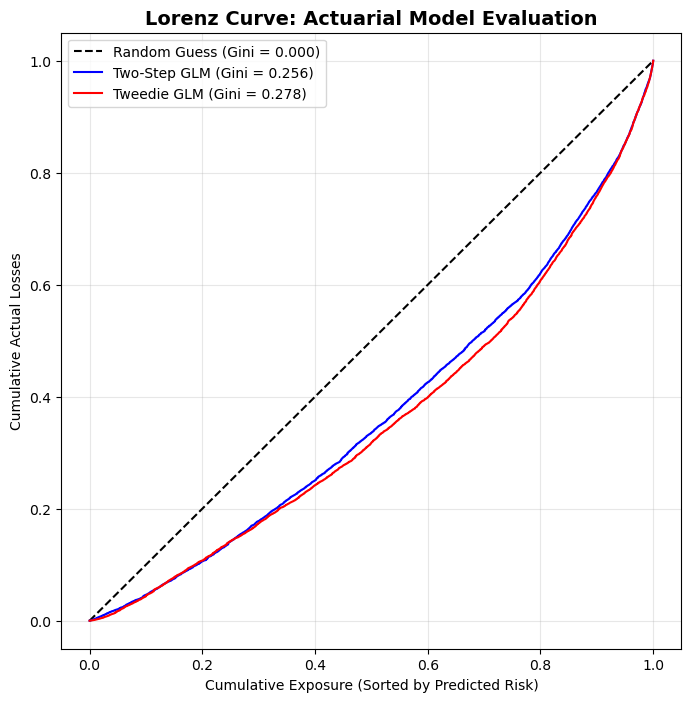

In [37]:
plt.figure(figsize=(8, 8))

# Plot the 45-degree Line of Equality (A model that guesses randomly)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random Guess (Gini = 0.000)')

# Plot the Two-Step Model
plt.plot(x_two, y_two, color='blue', label=f'Two-Step GLM (Gini = {gini_two:.3f})')

# Plot the Tweedie Model
plt.plot(x_tw, y_tw, color='red', label=f'Tweedie GLM (Gini = {gini_tw:.3f})')

plt.title('Lorenz Curve: Actuarial Model Evaluation', fontsize=14, fontweight='bold')
plt.xlabel('Cumulative Exposure (Sorted by Predicted Risk)')
plt.ylabel('Cumulative Actual Losses')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
features = ['BonusMalus', 'DrivAge', 'VehAge', 'VehGas']
X = pd.get_dummies(df_master[features], drop_first=True)

y = df_master['Pure_Premium_Capped']
exposure = df_master['Exposure']

xgb_model = xgb.XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5, 
    n_estimators=100,           
    learning_rate=0.1,          
    max_depth=3,                
    random_state=42
)
xgb_model.fit(X, y, sample_weight=exposure)

df_master['Pred_PP_XGB'] = xgb_model.predict(X)

x_xgb, y_xgb, gini_xgb = calculate_lorenz_and_gini(
    df_master, 'Pred_PP_XGB', 'Total_Claim_Amount_Capped', 'Exposure'
)

print(f"Two-Step GLM Gini: {gini_two:.4f}")
print(f"Tweedie GLM Gini:  {gini_tw:.4f}")
print(f"XGBoost Gini:      {gini_xgb:.4f}")

Two-Step GLM Gini: 0.2563
Tweedie GLM Gini:  0.2782
XGBoost Gini:      0.3376


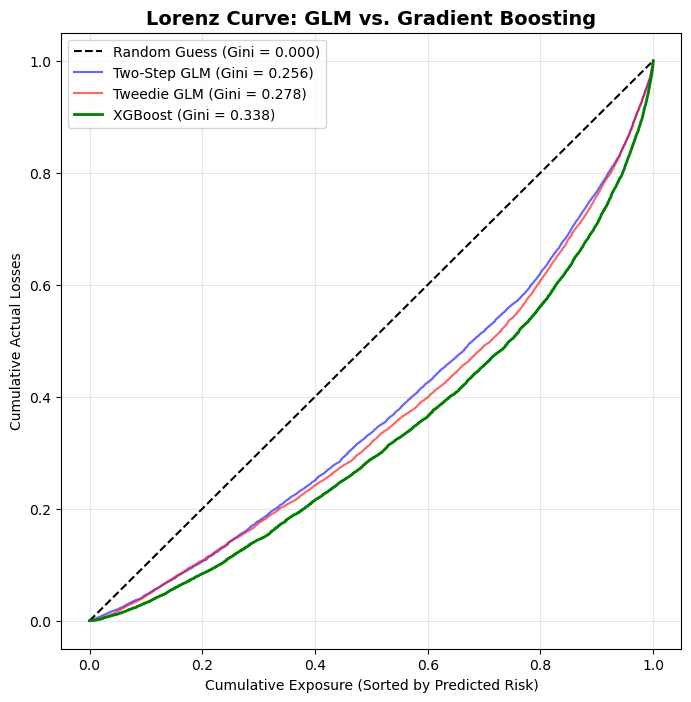

In [47]:
plt.figure(figsize=(8, 8))

# 45-degree Line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random Guess (Gini = 0.000)')

plt.plot(x_two, y_two, color='blue', alpha=0.6, label=f'Two-Step GLM (Gini = {gini_two:.3f})')
plt.plot(x_tw, y_tw, color='red', alpha=0.6, label=f'Tweedie GLM (Gini = {gini_tw:.3f})')

# Machine Learning Benchmark
plt.plot(x_xgb, y_xgb, color='green', linewidth=2, label=f'XGBoost (Gini = {gini_xgb:.3f})')

plt.title('Lorenz Curve: GLM vs. Gradient Boosting', fontsize=14, fontweight='bold')
plt.xlabel('Cumulative Exposure (Sorted by Predicted Risk)')
plt.ylabel('Cumulative Actual Losses')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

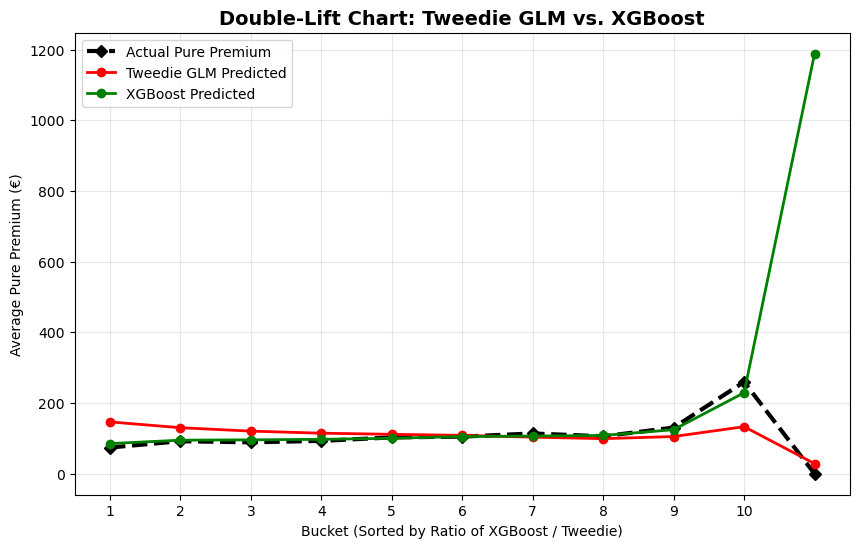

In [48]:
df_master['Model_Ratio'] = df_master['Pred_PP_XGB'] / df_master['Pred_PP_Tweedie']

df_sorted = df_master.sort_values(by='Model_Ratio').copy()
df_sorted['Cum_Exposure'] = df_sorted['Exposure'].cumsum()
total_exp = df_sorted['Exposure'].sum()
df_sorted['Bucket'] = np.ceil((df_sorted['Cum_Exposure'] / total_exp) * 10)
df_sorted['Pred_Amount_Tweedie'] = df_sorted['Pred_PP_Tweedie'] * df_sorted['Exposure']
df_sorted['Pred_Amount_XGB'] = df_sorted['Pred_PP_XGB'] * df_sorted['Exposure']

lift_summary = df_sorted.groupby('Bucket').agg(
    Total_Exposure=('Exposure', 'sum'),
    Actual_Losses=('Total_Claim_Amount_Capped', 'sum'),
    Tweedie_Losses=('Pred_Amount_Tweedie', 'sum'),
    XGB_Losses=('Pred_Amount_XGB', 'sum')
).reset_index()

lift_summary['Actual_PP'] = lift_summary['Actual_Losses'] / lift_summary['Total_Exposure']
lift_summary['Tweedie_PP'] = lift_summary['Tweedie_Losses'] / lift_summary['Total_Exposure']
lift_summary['XGB_PP'] = lift_summary['XGB_Losses'] / lift_summary['Total_Exposure']

plt.figure(figsize=(10, 6))

plt.plot(lift_summary['Bucket'], lift_summary['Actual_PP'], 
         color='black', linestyle='--', linewidth=3, marker='D', label='Actual Pure Premium')

plt.plot(lift_summary['Bucket'], lift_summary['Tweedie_PP'], 
         color='red', linewidth=2, marker='o', label='Tweedie GLM Predicted')
plt.plot(lift_summary['Bucket'], lift_summary['XGB_PP'], 
         color='green', linewidth=2, marker='o', label='XGBoost Predicted')

plt.title('Double-Lift Chart: Tweedie GLM vs. XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Bucket (Sorted by Ratio of XGBoost / Tweedie)')
plt.ylabel('Average Pure Premium (€)')
plt.xticks(np.arange(1, 11, 1)) # Force x-axis to show buckets 1-10
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Overview:

This project was the first real pricing project I have done, so there were some learning curves. First, I needed to get the data from two sources and join based off of the primary key IDpol. I then needed to modify the claim amounts by dividing each claim's respective exposure (after aggregating the claims by IDpol). This was necessary because different people have had different time while under the policy. I then needed to fill in any N/A claim amounts with 0. I then capped extreme tail-severities at the 99th percentile to simulate a Basic Limit. Which led to any amount above €18,278.38 to be capped. After getting my data set up, I started on the glms. I did a poisson glm for frequency and a gamma glm for severity. I also did a Tweedie glm. I learned what a Tweedie glm was from Computational Actuarial Science with R. When plotting both on a Lorenz curve, we were able to see that the Tweedie model did slightly better than our two-step glm. However, with a better performance comes abstraction. With the two-step glm, we could see all of our coefficients for both our frequency and severity models. With the Tweedie model, we only have one set of coefficients, which makes it harder to show why coefficients would increase or decrease in the future. After, I used XGBoost (gradient boost) in order to see what a machine learning model that would definitely do better look like compared to my other glms. It turns out XGBoost did a much better job as seen by its Gini coefficient. However, there were some issues. In the double-lift chart separated into buckets, XGBoost does a wonderful job following the Pure premium, but fails in bucket 10. Also, with abstraction comes difficulty to see why. This is a tree regression model, so picking out coefficients and justifying cost increases or decreases is much easier with a glm than XGBoost. To conclude, this was a great introductory project that allowed me to see why glms are the industry standard.